In [1]:
import time
import h5py

import numpy as np
import matplotlib.pyplot as plt
import sys

from chemrixs.average import Average
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
from chemrixs.utils import *
from pathlib import Path
%matplotlib widget 

In [2]:
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'

bgrun = 61
runs=[66]

exp = 'rix101331225'


fyaml = '../roi_input.yml'

bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
bgyaml = '../BGroi_input.yml'

# avg = Average(runs, proc_path = 'proc/Run', avg = 'mean', output_path = f'avg/{runs[0]}_to_{runs[-1]}.h5',
#              raw_path = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run' , bgpath = bgname, fyaml=fyaml, bgyaml=bgyaml, 
#              save= True,norm = True)

# avg.plot_svls2D(figsize=(12,4),savefig=True)


In [3]:
run = runs[0]

fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
fyaml = '../roi_inputTT.yml'
bgyaml = '../BGroi_input.yml'

data = SmallData(fname,fyaml)
# bg = SmallData(bgname, bgyaml)

<KeysViewHDF5 ['lxt_ttc', 'step_value']>
66
setting up properties
dataset prop <functools.cached_property object at 0x7f1d7eed7c50>
dataset prop <functools.cached_property object at 0x7f1d7db3e7d0>
dataset prop <functools.cached_property object at 0x7f21840e80d0>
dataset prop <functools.cached_property object at 0x7f1d7eea8d10>
dataset prop <functools.cached_property object at 0x7f1d7eeb8ad0>
dataset prop <functools.cached_property object at 0x7f1d7d8e1150>
dataset prop <functools.cached_property object at 0x7f1d7e56a110>
dataset prop <functools.cached_property object at 0x7f1d7d8e1910>


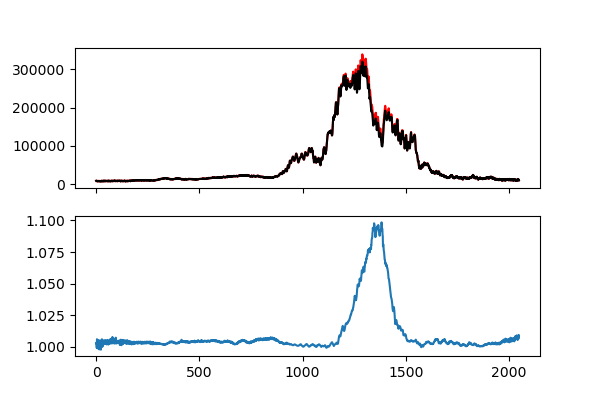

In [4]:
import scipy.stats as st
expected_count = st.mode(data.integrating.axis_svls.count, keepdims=False)[0]

data.integrating.axis_svls.piranha.shape
# data.integrating.axis_svls.eventcodes.shape[:,272]
mask_on = np.asarray([data.integrating.axis_svls.eventcodes[:,data.yaml['evc'][True]]/expected_count>0.5]).squeeze()
mask_off = np.asarray([data.integrating.axis_svls.eventcodes[:,data.yaml['evc'][False]]/expected_count>0.5]).squeeze()
piranha_on = data.integrating.axis_svls.piranha[mask_on,:]
piranha_off = data.integrating.axis_svls.piranha[mask_off,:]

fig,ax=plt.subplots(2,1,figsize=(6,4),sharex=True)
ax[0].plot(np.nanmean(piranha_on,axis=0).T, 'r')
ax[0].plot(np.nanmean(piranha_off,axis=0).T, 'k')
ax[1].plot((np.nanmean(piranha_on,axis=0))/(np.mean(piranha_off,axis=0)))

In [5]:
def reconst_svd(u,s,v,N):
    
    data_denoised = (u[:, :N] * s[:N]) @ v[:N, :]
    return data_denoised

def reconst_singlecomp(u,s,v,x):
    component_x = s[x] * np.outer(u[:, x], v[x, :])
    return component_x

In [6]:
#####SLAC EXAMPLE SVD.py SCRIPTS######################

# LS Waveform SVD functions 
def decomp_(waves,nevts):    
    # randomly pick up nevts events
    if nevts<waves.shape[0]:
        idx = np.array(random.sample(range(0,waves.shape[0]),nevts))
        # print(idx)
    else:
        idx = np.arange(waves.shape[0])
    start,end = (0,waves.shape[1])  #which section of waveform to use for svd.  use to select out saturation region

    #instead manually calculate svd by using the smaller lh sv.
    s,u = np.linalg.eigh(np.dot(waves[idx,start:end],waves[idx,start:end].transpose()))
    v = np.dot(np.linalg.pinv(u),waves[idx,start:end])

 # get the real component of the eigenvector
    temp = np.array([i/np.dot(i,i)**0.5 for i in v[:]])#normalizing
    v = np.real(temp)
    #print(s.shape,v.shape, np.flipud(s).shape, np.flipud(v).shape)
    return np.flipud(v)[:1000],np.flipud(s)[:1000]


def decomp_1d(vec_dark,val_dark,wfs,ROI_svd,neigs = 2):  # this function does pixel-resolved singular value decomposition
    # ROI SVD 
    #print(val_dark[:neigs].sum()/val_dark.sum())
    target_1d = wfs
    bg_mask = (wfs[0]*0+1).astype(bool)
    bg_mask[ROI_svd[0]:ROI_svd[1]]=False 
    signal_1d = target_1d/np.dot(np.dot(target_1d[:,bg_mask],np.linalg.pinv(vec_dark[:neigs][:,bg_mask])),vec_dark[:neigs])

    return signal_1d[:,ROI_svd[0]:ROI_svd[1]]

# v, s = decomp_(dat[loff],2000) #decomposition of BG data (dark)
# sl = slice(0,-1)
# traces = decomp_1d(v,s,dat[:,:][:],ROI) #all data only ROI


In [7]:
import numpy as np

def gaussian_moments(x, y):
    """
    Fast Gaussian fit using moments.

    Returns
    -------
    A     : amplitude
    mu    : center
    sigma : width
    C     : offset
    """

    # estimate offset from edges
    C = np.median(np.concatenate([y[:10], y[-10:]]))
    y0 = y - C

    # guard against bad curves
    if np.all(y0 <= 0):
        return np.nan, np.nan, np.nan, C

    y0 = np.clip(y0, 0, None)

    norm = np.sum(y0)
    mu = np.sum(x * y0) / norm
    sigma = np.sqrt(np.sum((x - mu)**2 * y0) / norm)
    A = np.max(y0)

    return A, mu, sigma, C

from scipy.optimize import curve_fit

def gaussian(x, A, mu, sigma, C):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + C


def fit_gaussian_fast(x, y, lb, ub):
    p0 = gaussian_moments(x, y)
    bounds = [lb, ub]

    if np.any(np.isnan(p0[:3])):
        return p0

    try:
        p0=np.asarray(p0)
        p0[p0<lb]= lb[p0<lb]
        p0[p0>ub]= ub[p0>ub]
        popt, _ = curve_fit(
            gaussian,
            x,
            y,
            p0=p0,
            bounds=bounds,
            maxfev=2000
        )
        return popt
    except RuntimeError:
        return p0
    



In [20]:
ROI=[1100,1600]
# u,s,v=np.linalg.svd((piranha_off[1:,:])[:2000,:])

v, s = decomp_((piranha_off[1:,:])[:1000,:],2000) #decomposition of BG data (dark)
traces = decomp_1d(v,s,data.integrating.axis_svls.piranha[-2000:,:],ROI,neigs=3) #all data only ROI

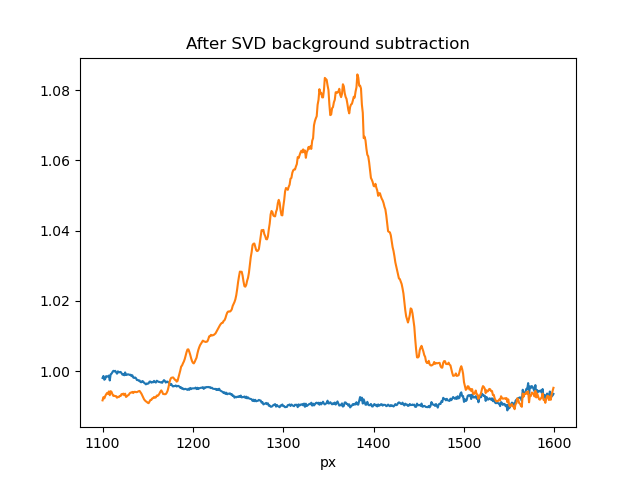

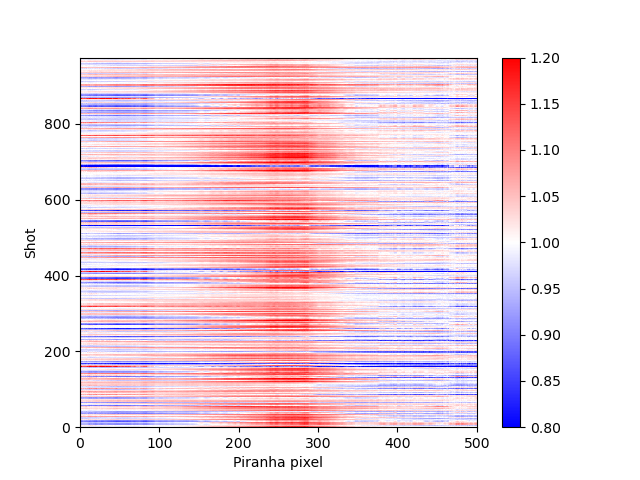

In [21]:


# l = 10

# fig,ax=plt.subplots(1,3,figsize=(10,3))

# for i in np.arange(l):
#     ax[0].plot(u[:,i]+np.max(u)/2*i)
#     ax[0].hlines(np.max(u)/2*i,0,u.shape[0])
# ax[1].scatter(np.arange(10),s[:10])
# for i in np.arange(l):
#     ax[2].plot(v[i,:]+np.max(v)*i/5)

px = np.arange(ROI[0],ROI[1])
plt.figure()
plt.plot(px,np.nanmean(traces[mask_off[-2000:],:],axis =0),label = 'Background')
plt.plot(px,np.nanmean(traces[mask_on[-2000:],:],axis =0),label = 'Signal')
plt.title('After SVD background subtraction')
plt.xlabel('px')
plt.show()
plt.figure()
shots = np.arange(len(traces[mask_on[-2000:]]))
plt.pcolormesh(traces[mask_on[-2000:]],cmap = 'bwr',vmin = 0.8,vmax = 1.2)
plt.xlabel('Piranha pixel')
plt.ylabel('Shot')
plt.colorbar()
plt.show()



In [22]:

px = np.arange(ROI[0],ROI[1])
x = px
spectra = traces[mask_on[:2000]]
spectra.shape == (traces[mask_on[:2000]].shape[0], traces[mask_on[:2000]].shape[1])
x.shape == (traces[mask_on[:2000]].shape[0],)
params = np.array([
    gaussian_moments(x, spectra[i])
    for i in range(spectra.shape[0])
])
lb = np.array([0.0,   1200,  10,   0.9])  # A, mu, sigma, C (lower)
ub = np.array([0.3,   1400, 40,  1.1])    
params_fit = np.array([
    fit_gaussian_fast(x, spectra[i],lb,ub)
    for i in range(spectra.shape[0])
])

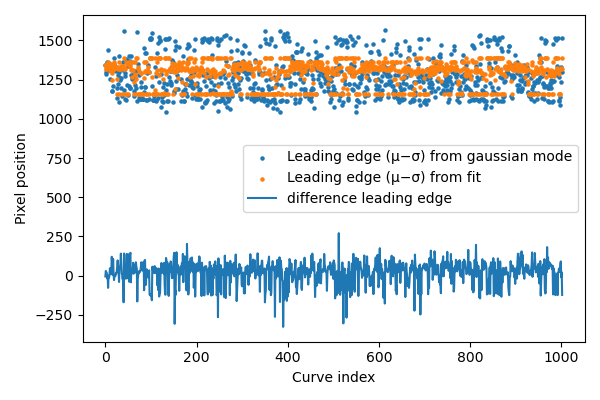

In [23]:
A     = params[:, 0]
mu    = params[:, 1]
sigma = params[:, 2]
A_fit     = params_fit[:, 0]
mu_fit    = params_fit[:, 1]
sigma_fit = params_fit[:, 2]

leading_edge  = mu - sigma
leading_edge_fit  = mu_fit - sigma_fit
# trailing_edge = mu + sigma

idx = np.arange(len(mu))  # curve index, delay index, shot index, etc.

plt.figure(figsize=(6,4))
plt.scatter(idx, leading_edge, s=5, label="Leading edge (μ−σ) from gaussian mode")
plt.scatter(idx, leading_edge_fit, s=5, label="Leading edge (μ−σ) from fit")
plt.plot(idx, leading_edge_fit-leading_edge, label="difference leading edge ")
# plt.scatter(idx, trailing_edge, s=5, label="Trailing edge (μ+σ)")
plt.xlabel("Curve index")
plt.ylabel("Pixel position")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
random

NameError: name 'random' is not defined

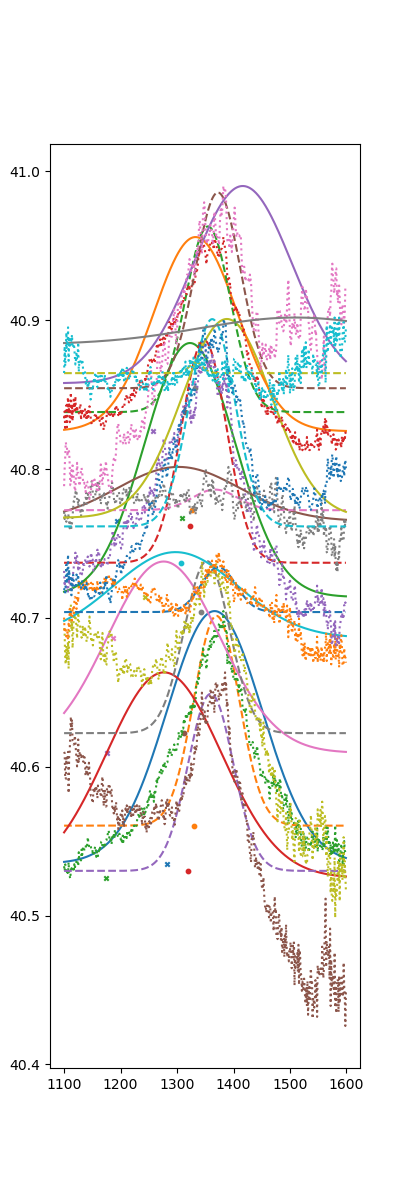

In [25]:
fig,ax =plt.subplots(1,1,figsize=(4,12))
for i in np.arange(910,920,1):
    ax.plot(px,gaussian(px,*params[i,:])+params[0,0]*i)
    ax.plot(px,gaussian(px,*params_fit[i,:])+params[0,0]*i,'--')
    ax.plot(px,spectra[i]+params[0,0]*i,':')
    ax.scatter(leading_edge[i],params[0,0]*i+params[i,-1],s=10,marker='x')
    ax.scatter(leading_edge_fit[i],params[0,0]*i+params_fit[i,-1],s=10,marker='o')

In [44]:
45*5

225

In [9]:
ROI=[900,1400]
# u,s,v=np.linalg.svd((piranha_off[1:,:])[:1000,:])

v, s = decomp_((piranha_off[1:,:])[:,:],2000) #decomposition of BG data (dark)
traces_decomp = decomp_1d(v,s,data.integrating.axis_svls.piranha,ROI) #all data only ROI

NameError: name 'random' is not defined

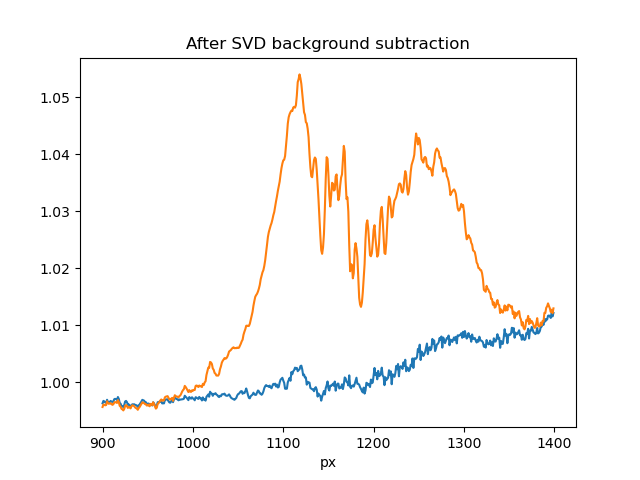

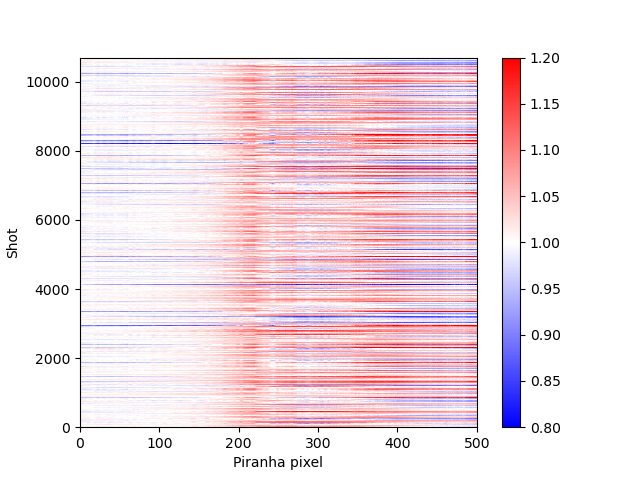

In [ ]:


# l = 10

# fig,ax=plt.subplots(1,3,figsize=(10,3))

# for i in np.arange(l):
#     ax[0].plot(u[:,i]+np.max(u)/2*i)
#     ax[0].hlines(np.max(u)/2*i,0,u.shape[0])
# ax[1].scatter(np.arange(10),s[:10])
# for i in np.arange(l):
#     ax[2].plot(v[i,:]+np.max(v)*i/5)

px = np.arange(ROI[0],ROI[1])
plt.figure()
plt.plot(px,np.nanmean(traces[mask_off,:],axis =0),label = 'Background')
plt.plot(px,np.nanmean(traces[mask_on,:],axis =0),label = 'Signal')
plt.title('After SVD background subtraction')
plt.xlabel('px')
plt.show()
plt.figure()
shots = np.arange(len(traces[mask_on]))
plt.pcolormesh(traces[mask_on],cmap = 'bwr',vmin = 0.8,vmax = 1.2)
plt.xlabel('Piranha pixel')
plt.ylabel('Shot')
plt.colorbar()
plt.show()



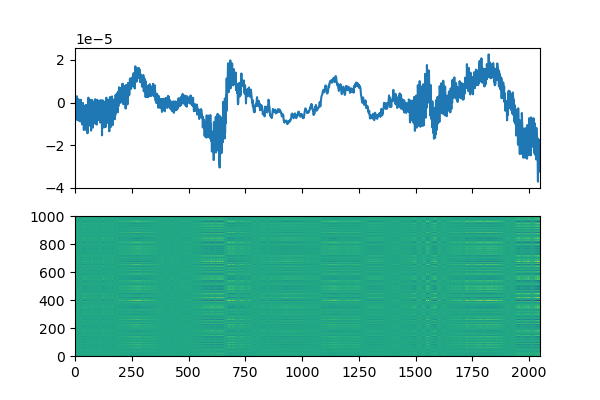

In [59]:
ind_comp = reconst_singlecomp(u,s,v,10)


noise_free = reconst_svd(u,s,v,9) 


fig,ax=plt.subplots(2,1,figsize=(6,4),sharex=True)
ax[0].plot(np.mean(ind_comp,axis=0))

ax[1].pcolor(ind_comp)

In [ ]:


noise_free = reconst_svd(u,s,v,9) 

piranha_on_nf = noise_free[mask_on,:]
piranha_off_nf = noise_free[mask_off,:]

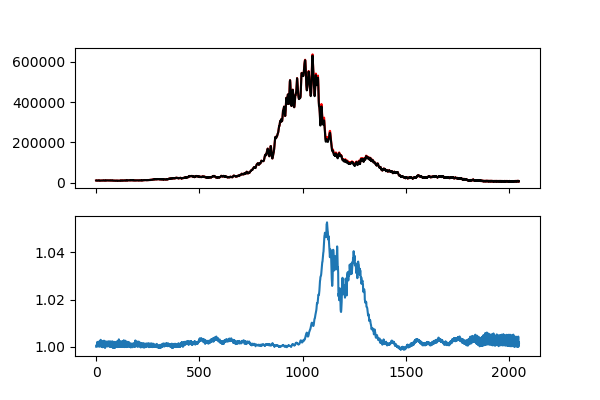

In [39]:
# pir_bg = np.mean(u[:,0])*s[0]*v[0,:]

fig,ax=plt.subplots(2,1,figsize=(6,4),sharex=True)
ax[0].plot(np.nanmean(piranha_on_nf,axis=0).T, 'r')
ax[0].plot(np.nanmean(piranha_off_nf,axis=0).T, 'k')
# ax[0].plot(pir_bg,linewidth=0.5)
ax[1].plot((np.nanmean(piranha_on_nf,axis=0))/(np.mean(piranha_off_nf,axis=0)))
# ax[1].plot((np.nanmean(piranha_on_nf[:,900:1500],axis=0))/pir_bg)

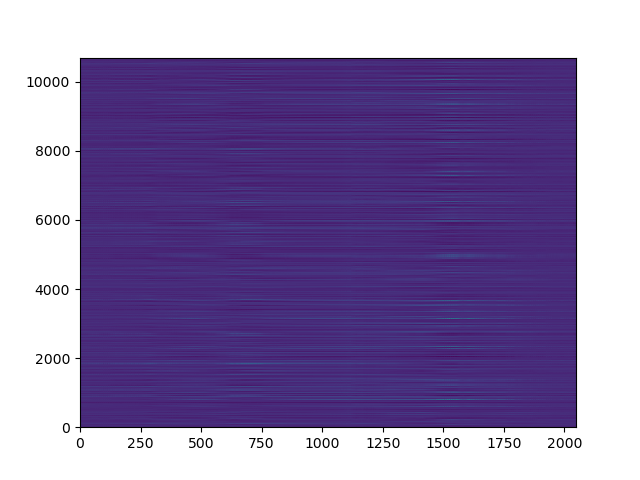

In [33]:
fig,ax=plt.subplots(1,1)

ax.pcolor(((piranha_on_nf)/(piranha_off_nf[1:,:])))

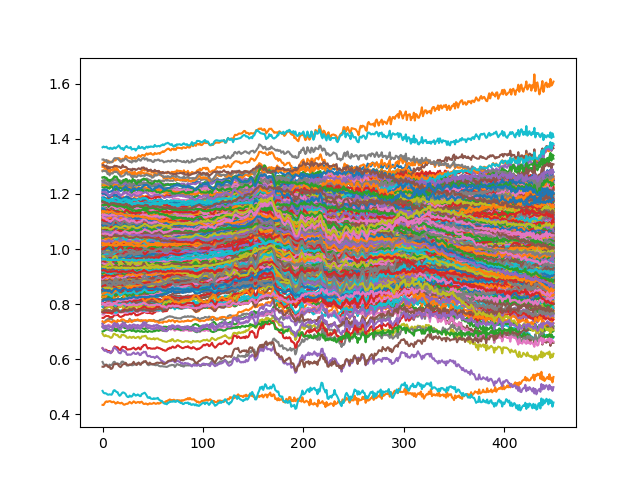

In [50]:
fig,ax=plt.subplots(1,1)

ax.plot((piranha_on/pir_bg)[:500,950:1400].T)

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(15,3))
ax.scatter(np.arange(len(data.integrating.axis_svls.mono))[data.integrating.axis_svls.eventcodes[:,272]==1],data.integrating.axis_svls.mono[data.integrating.axis_svls.eventcodes[:,272]==1],color='r',s=2,label='laser on')
ax.scatter(np.arange(len(data.integrating.axis_svls.mono))[data.integrating.axis_svls.eventcodes[:,273]==1],data.integrating.axis_svls.mono[data.integrating.axis_svls.eventcodes[:,273]==1],color='k',s=2,label='laser off')
ax.legend()
ax.set_xlim([0,len(data.integrating.axis_svls.mono)])
# fig.savefig('figs/mono_move_onoff.png',dpi=200,bbox_inches='tight')


In [ ]:
for run in runs:
    fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
    red = Reduced(fname,bgname,fyaml,bgyaml, save=True)



avg=avg_data(runs,proc_folder)

In [ ]:
red.data.integrating.axis_svls.mono.max()

In [ ]:
fig,ax=plt.subplots()
ax.plot(np.nansum(red.data.integrating.axis_svls.full_area,axis=0),'k',label='data')
ax.plot(np.nansum(red.bg.integrating.axis_svls.full_area,axis=0),'r',alpha=0.5,label='background')
ax.legend()
# ax.plot(np.nansum(red.proc,axis=0),'k')
# ax.plot(np.nansum(red.proc.svls,axis=0),'r')

In [ ]:
fig,ax=plt.subplots(1,1)
ax.plot(red.scanvar_on,np.sum(red.axis_svls_on_mean,1)-np.sum(red.axis_svls_off_mean,1))
ax.plot(red.scanvar_off,np.sum(red.axis_svls_off_mean,1))
# ax.set_xlim([red.scanvar_on.min(),red.scanvar_on.max()])

In [ ]:
fig,ax=plt.subplots(1,3,figsize=(9,3),sharex=True,sharey=True)
ax[0].pcolor(avg['scanvar_on'],np.arange(avg['axis_svls_on_sum'].shape[1]),avg['axis_svls_on_sum'].T,cmap='terrain_r',vmin=0,vmax=np.nanmax(avg['axis_svls_on_sum']))
ax[1].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),avg['axis_svls_off_sum'].T,cmap='terrain_r',vmin=0,vmax=np.nanmax(avg['axis_svls_off_sum']))
ddat=np.nanmax(np.abs(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']))
ax[2].pcolor(avg['scanvar_on'],np.arange(avg['axis_svls_on_sum'].shape[1]),(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']).T,cmap='RdBu')
ax[0].set_xlim([avg['scanvar_off'].min(),avg['scanvar_off'].max()])

In [ ]:
emi_calib = [0.06521910251275982, 534.809958523687]
points=[[569.5,533],[573.2,589]]
mono_inc = 530

# if emi_calib == []:
#     if data.runinfo == 'mono':
emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
            dat=avg['axis_svls_sum'], 
            mono = avg['scanvar'], 
            calib=emi_calib, 
                points = points)
#     else:
#         print('need mono scan to calibrate using emission axis')
# else:
#     emi,calib =pixel2emi(np.arange(avg['axis_svls_sum'].shape[1]), mono=[],
#                     dat=avg['axis_svls_sum'], 
#                     calib=emi_calib) 
                    
# if data.runinfo == 'mono':
mono, E_trans_on, data_trans_on=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
mono, E_trans_off, data_trans_off=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
# else:
#     E_trans = mono_inc - emi

fig,ax=plt.subplots(1,3, sharex=True, sharey=True)
ax[0].pcolor(mono,E_trans_on, data_trans_on.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_on))
ax[1].pcolor(mono,E_trans_off, data_trans_off.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_off))
ax[2].pcolor(mono,E_trans_on, (data_trans_on-data_trans_off).T,vmin=np.min((data_trans_on-data_trans_off)),cmap='terrain_r',vmax=np.max((data_trans_on-data_trans_off)))

In [ ]:
emi_calib = [0.06521910251275982, 534.809958523687]
points=[[569.5,533],[573.2,589]]
mono_inc = 530

if emi_calib == []:
    if data.scantype == 'mono':
        emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
                    avg['axis_svls_on_sum'], 
                    mono = avg['scanvar_on'], 
                    calib=emi_calib, 
                    points = points)
    else:
        print('need mono scan to calibrate using emission axis')
else:
    emi,calib =pixel2emi(np.arange(avg['axis_svls_on_sum'].shape[1]), 
                    avg['axis_svls_on_sum'], 
                    calib=emi_calib) 
                    
if data.scantype == 'mono':
    mono, E_trans_on, data_trans_on=emi2ET(avg['scanvar_on'],emi,avg['axis_svls_on_sum'],step=0.1)
    mono, E_trans_off, data_trans_off=emi2ET(avg['scanvar_off'],emi,avg['axis_svls_off_sum'],step=0.1)
else:
    E_trans = mono_inc - emi

fig,ax=plt.subplots(1,3, sharex=True, sharey=True)
ax[0].pcolor(mono,E_trans_on, data_trans_on.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_on))
ax[1].pcolor(mono,E_trans_off, data_trans_off.T,cmap='terrain_r',vmin=-0,vmax=np.max(data_trans_off))
ax[2].pcolor(mono,E_trans_on, (data_trans_on-data_trans_off).T,vmin=np.min((data_trans_on-data_trans_off)),cmap='terrain_r',vmax=np.max((data_trans_on-data_trans_off)))

In [ ]:
fig,ax=plt.subplots(1,3)
ax[0].pcolor(avg['scanvar_on'],emi,avg['axis_svls_on_sum'].T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_on_sum']))
ax[1].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),avg['axis_svls_off_sum'].T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_off_sum']))
ax[2].pcolor(avg['scanvar_off'],np.arange(avg['axis_svls_off_sum'].shape[1]),(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']).T,cmap='terrain_r',vmin=-0,vmax=np.max(avg['axis_svls_on_sum']-avg['axis_svls_off_sum']))



In [ ]:

fig,ax=plt.subplots(1,3)
ax[0].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_off_mean))
ax[1].pcolor(red.scanvar_off,np.arange(red.axis_svls_off_mean.shape[1]),red.axis_svls_off_mean.T,cmap='terrain_r',vmin=0,vmax=np.max(red.axis_svls_off_mean))
ax[2].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T-red.axis_svls_off_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_on_mean-red.axis_svls_off_mean))


In [ ]:
data.singleshot.fim_0.full_area
bg_roi=[0,50]
bg = np.mean(data.singleshot.fim_0.full_area[...,bg_roi[0]:bg_roi[1]],axis= -1)
bgf = data.singleshot.fim_0.full_area - bg[...,np.newaxis]

In [ ]:
fim_roi=[60,70]

fim_proc =subtract_bg(data.singleshot.fim_0.full_area,[0,50])
fim_wf_avs = np.nanmean(fim_proc,axis = 0)
# fim = np.sum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = (1,2))

# fim = np.nansum(fim_proc[:,:,fim_roi[0]:fim_roi[1]],axis = (1,2))

fim_sum_all = np.nansum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = 2)

In [6]:
# run=76
# fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
# test = h5py.File(fname, 'r')
#run=142
#fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
run=84
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
test1 = h5py.File(fname, 'r')
test1['intg']['axis_svls'].keys()
# test1['scan']['lxt_ttc']

<KeysViewHDF5 ['c_piranha_sum_full_area', 'count', 'crix_w8_sum_base_0', 'crix_w8_sum_base_1', 'crix_w8_sum_base_2', 'crix_w8_sum_base_3', 'crix_w8_sum_base_4', 'crix_w8_sum_base_5', 'crix_w8_sum_base_6', 'crix_w8_sum_base_7', 'crix_w8_sum_base_all', 'crix_w8_sum_integral_0', 'crix_w8_sum_integral_1', 'crix_w8_sum_integral_2', 'crix_w8_sum_integral_3', 'crix_w8_sum_integral_4', 'crix_w8_sum_integral_5', 'crix_w8_sum_integral_6', 'crix_w8_sum_integral_7', 'crix_w8_sum_integral_all', 'crix_w8_sum_intensity', 'crix_w8_sum_itrigCount', 'crix_w8_sum_posX', 'crix_w8_sum_posY', 'crix_w8_sum_ptrigCount', 'det_crix_w8_sum_full_area', 'det_crix_w8_sum_wfintegrate', 'det_rix_fim0_sum_full_area', 'det_rix_fim0_sum_wfintegrate', 'det_rix_fim1_sum_full_area', 'det_rix_fim1_sum_wfintegrate', 'droplet_dense_curve_corr_corrected_image', 'droplet_dense_curve_corr_pj_ax_1_data', 'droplet_nDroplets', 'droplet_nDroplets_all', 'gmd_sum_RMS_E1', 'gmd_sum_RMS_E1_sevr', 'gmd_sum_milliJoulesPerPulse', 'gmd_sum_

In [ ]:
premirror = get_premirror_pitch(red.data.epics['MONO_premirror_pitch'][:])
hrencoder = red.data.integrating.andor_vls.mono_encoder
hr_pitch = hrencoder_to_pitch(hrencoder, red.data.yaml['mono_calib'])
hr_energy = mono_energy(hr_pitch,premirror)
hr_energy

In [ ]:
testfile = h5py.File('testsave.h5','w')
keys = vars(red)
avg = {}
for key in keys:
    avg[key] = np.zeros(testfile[key].shape)

for dat in keys:
    if 'on' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])
    elif 'off' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])


testfile.close()

In [ ]:
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
with h5py.File(fname) as tmp:
    h5dump(tmp)


In [6]:

import dask.array as da
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'
exp = 'rix101331225'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run0066.h5'


with h5py.File(fname,'r') as file:
    print(file['intg']['axis_svls'].keys())
    test=da.from_array(file['intg']['axis_svls']['det_crix_w8_sum_full_area'], chunks = 'auto')
    # ax.plot(np.nanmean(file['intg']['axis_svls']['curve_corr_corrected_image'],axis=0))
    # fh = h5py.File(fname, 'r')
    test_ims_thresh = file['intg/axis_svls/curve_corr_corrected_image'][:20,:][...]
    test_los_thresh = file['intg/axis_svls/curve_corr_pj_ax_1_data'][:,:][...]
plt.figure()
plt.subplot(211)
plt.plot(np.nanmean(test_los_thresh,axis =0),label = 'curve_corr_pj_ax_1_data')
plt.legend()
plt.subplot(212)
plt.plot(np.nanmean(test_ims_thresh,axis =(0,2)),label = 'lineout from curve_corr_corrected_image')
plt.xlabel('pixel')
# Plt.legend()
plt.show()

<KeysViewHDF5 ['c_piranha_sum_full_area', 'count', 'crix_w8_sum_base_0', 'crix_w8_sum_base_1', 'crix_w8_sum_base_2', 'crix_w8_sum_base_3', 'crix_w8_sum_base_4', 'crix_w8_sum_base_5', 'crix_w8_sum_base_6', 'crix_w8_sum_base_7', 'crix_w8_sum_base_all', 'crix_w8_sum_integral_0', 'crix_w8_sum_integral_1', 'crix_w8_sum_integral_2', 'crix_w8_sum_integral_3', 'crix_w8_sum_integral_4', 'crix_w8_sum_integral_5', 'crix_w8_sum_integral_6', 'crix_w8_sum_integral_7', 'crix_w8_sum_integral_all', 'crix_w8_sum_intensity', 'crix_w8_sum_itrigCount', 'crix_w8_sum_posX', 'crix_w8_sum_posY', 'crix_w8_sum_ptrigCount', 'det_crix_w8_sum_full_area', 'det_crix_w8_sum_wfintegrate', 'det_rix_fim0_sum_full_area', 'det_rix_fim0_sum_wfintegrate', 'det_rix_fim1_sum_full_area', 'det_rix_fim1_sum_wfintegrate', 'droplet_dense_curve_corr_corrected_image', 'droplet_dense_curve_corr_pj_ax_1_data', 'droplet_nDroplets', 'droplet_nDroplets_all', 'lightStatus_sum_laser', 'lightStatus_sum_xray', 'mono_hrencoder_sum_value', 'rix

KeyError: "Unable to synchronously open object (object 'curve_corr_corrected_image' doesn't exist)"

In [10]:
test_ims_thresh.sum()

0.0